# Titanic Survivors — Improved Feature Engineering & Model Training

This is an improved version of `titanic_eda.ipynb` with:
- Additional features (TicketFreq, Deck, AgeBin, FareBin, FamilySizeBin, Sex×Pclass)
- Scoring metric changed from F1 to **accuracy** (matching Kaggle's public score)
- Accuracy-based threshold tuning
- Retraining on full training data before final submission

This notebook covers:
1. Loading the raw Titanic datasets
2. Exploratory Data Analysis (EDA)
3. Feature extraction and engineering
4. Splitting the training data into an 80% train / 20% validation set

**Kaggle scoring**: The Titanic competition uses **accuracy** (percentage of correct predictions) as its public score metric.

## 1  Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_recall_curve
import random
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.model_selection import GridSearchCV

%matplotlib inline
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2  Load Data

> Place `train.csv`, `test.csv`, and `gender_submission.csv` inside the `data/` folder.  
> See `data/README.md` for download instructions.

In [10]:
train_raw = pd.read_csv('data/train.csv')
test_raw  = pd.read_csv('data/test.csv')

print(f'Training set : {train_raw.shape[0]} rows × {train_raw.shape[1]} columns')
print(f'Test set     : {test_raw.shape[0]} rows × {test_raw.shape[1]} columns')
train_raw.head()

Training set : 891 rows × 12 columns
Test set     : 418 rows × 11 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3  Exploratory Data Analysis

In [11]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
train_raw.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [13]:
# Missing-value summary
missing = train_raw.isnull().sum().rename('missing').to_frame()
missing['pct'] = (missing['missing'] / len(train_raw) * 100).round(2)
missing[missing['missing'] > 0].sort_values('pct', ascending=False)

,missing,pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


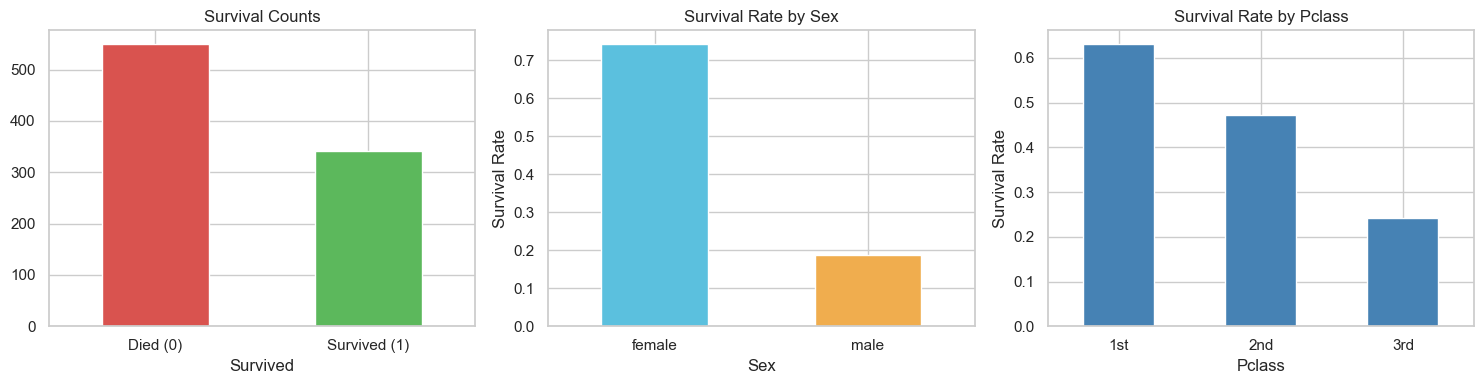

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival rate
train_raw['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'])
axes[0].set_title('Survival Counts')
axes[0].set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)

# Survival by Sex
train_raw.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['#5bc0de', '#f0ad4e'])
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Survival by Pclass
train_raw.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Survival Rate by Pclass')
axes[2].set_ylabel('Survival Rate')
axes[2].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

plt.tight_layout()
plt.show()

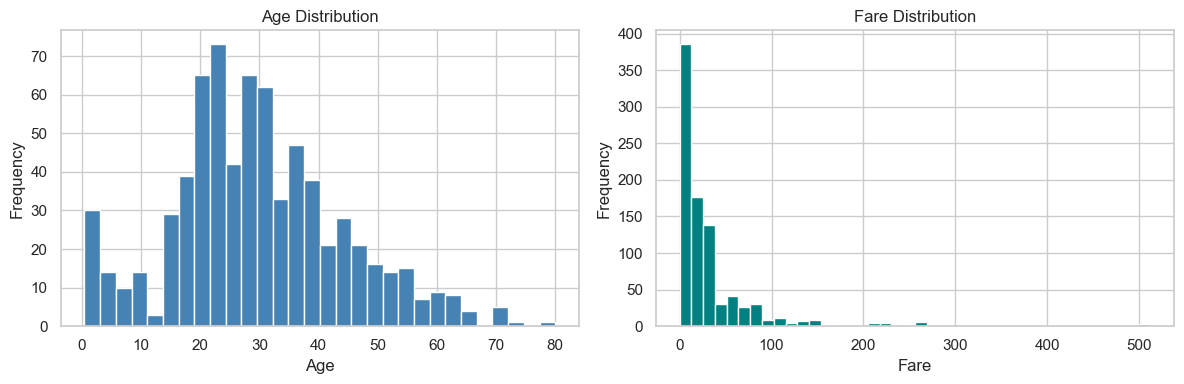

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
train_raw['Age'].plot(kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# Fare distribution
train_raw['Fare'].plot(kind='hist', bins=40, ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

## 4  Feature Engineering

We apply the same transformations to both the training and test sets to avoid data leakage and ensure consistency.

| Step | Action |
|------|--------|
| `Title` | Extract title from passenger name as a social-status proxy |
| `FamilySize` | `SibSp + Parch + 1` — total people in family unit |
| `IsAlone` | Binary flag: 1 if travelling alone, else 0 |
| `FamilySizeBin` | Categorize family: Solo / Small (2-4) / Large (5+) |
| `Age` | Impute missing values with the median age per title group |
| `AgeBin` | Binned age into Child / Teen / Adult / Senior |
| `Fare` | Impute one missing test value with the overall median |
| `FareBin` | Quartile-based fare bins |
| `Embarked` | Impute two missing values with the mode (`S`) |
| `TicketFreq` | Number of passengers sharing the same ticket |
| `Deck` | First letter of Cabin (or 'U' for unknown) |
| `Sex_Pclass` | Interaction: Sex × Pclass for capturing gender-class effects |
| Encoding | Label-encode `Sex`; one-hot-encode `Embarked`, `Title`, `Deck`, `AgeBin`, `FareBin`, `FamilySizeBin` |
| Drop | Remove `PassengerId`, `Name`, `Ticket`, `Cabin` (high cardinality / mostly missing) |

In [16]:
def engineer_features(df: pd.DataFrame, ticket_freq_map: dict = None) -> pd.DataFrame:
    df = df.copy()

    # --- Title -----------------------------------------------------------
    df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
    # Consolidate rare titles
    rare_titles = {'Dona', 'Lady', 'Countess', 'the Countess', 'Capt', 'Col', 'Don',
                   'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer'}
    df['Title'] = df['Title'].replace(list(rare_titles), 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # --- Family size -----------------------------------------------------
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # --- Family size bins ------------------------------------------------
    df['FamilySizeBin'] = pd.cut(df['FamilySize'],
                                 bins=[0, 1, 4, 20],
                                 labels=['Solo', 'Small', 'Large'])

    # --- Impute Age (median per Title, with global-median fallback) ------
    title_age_medians = df.groupby('Title')['Age'].median()
    df['Age'] = df['Age'].fillna(df['Title'].map(title_age_medians))
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # --- Age bins --------------------------------------------------------
    df['AgeBin'] = pd.cut(df['Age'],
                          bins=[0, 12, 18, 60, 120],
                          labels=['Child', 'Teen', 'Adult', 'Senior'])

    # --- Impute Fare & Embarked ------------------------------------------
    df['Fare']     = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # --- Fare bins (quartile-based) --------------------------------------
    df['FareBin'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Mid', 'High', 'VeryHigh'],
                            duplicates='drop')

    # --- Ticket frequency (group travel proxy) ---------------------------
    if ticket_freq_map is not None:
        df['TicketFreq'] = df['Ticket'].map(ticket_freq_map).fillna(1).astype(int)
    else:
        df['TicketFreq'] = df.groupby('Ticket')['Ticket'].transform('count')

    # --- Deck from Cabin -------------------------------------------------
    df['Deck'] = df['Cabin'].str[0].fillna('U')

    # --- Encode Sex ------------------------------------------------------
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    # --- Interaction: Sex x Pclass ---------------------------------------
    df['Sex_Pclass'] = df['Sex'] * df['Pclass']

    # --- One-hot encode Embarked, Title, Deck, AgeBin, FareBin, FamilySizeBin
    df = pd.get_dummies(df, columns=['Embarked', 'Title', 'Deck', 'AgeBin',
                                     'FareBin', 'FamilySizeBin'], drop_first=False)

    # --- Drop columns not used as features ------------------------------
    drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df


# Build ticket frequency map from combined train+test to avoid leakage issues
all_tickets = pd.concat([train_raw['Ticket'], test_raw['Ticket']])
ticket_freq_map = all_tickets.value_counts().to_dict()

train_eng = engineer_features(train_raw, ticket_freq_map)
test_eng  = engineer_features(test_raw,  ticket_freq_map)

# Align test columns to training columns (excluding target)
feature_cols = [c for c in train_eng.columns if c != 'Survived']
# Warn if test set has categories not seen during training
unseen = [c for c in test_eng.columns if c not in feature_cols]
if unseen:
    print(f'Warning: test set has unseen columns that will be dropped: {unseen}')
test_eng = test_eng.reindex(columns=feature_cols, fill_value=0)

print('Engineered training set shape :', train_eng.shape)
print('Engineered test set shape     :', test_eng.shape)
train_eng.head()

Engineered training set shape : (891, 39)
Engineered test set shape     : (418, 38)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketFreq,...,AgeBin_Teen,AgeBin_Adult,AgeBin_Senior,FareBin_Low,FareBin_Mid,FareBin_High,FareBin_VeryHigh,FamilySizeBin_Solo,FamilySizeBin_Small,FamilySizeBin_Large
0,0,3,0,22.0,1,0,7.2500,2,0,1,...,False,True,False,True,False,False,False,False,True,False
1,1,1,1,38.0,1,0,71.2833,2,0,2,...,False,True,False,False,False,False,True,False,True,False
2,1,3,1,26.0,0,0,7.9250,1,1,1,...,False,True,False,False,True,False,False,True,False,False
3,1,1,1,35.0,1,0,53.1000,2,0,2,...,False,True,False,False,False,False,True,False,True,False
4,0,3,0,35.0,0,0,8.0500,1,1,1,...,False,True,False,False,True,False,False,True,False,False


In [17]:
# Confirm no missing values remain in training set
missing_after = train_eng.isnull().sum()
print('Columns still containing NaN:', missing_after[missing_after > 0].to_dict() or 'None ✓')

Columns still containing NaN: None ✓


## 5  Train / Validation Split (80 / 20)

We use a stratified split to preserve the class distribution.

In [18]:
X = train_eng.drop(columns=['Survived'])
y = train_eng['Survived']
groups_all = train_raw.loc[train_eng.index, 'Ticket'].astype(str).values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, va_idx = next(gss.split(X, y, groups=groups_all))

train_df, val_df = train_eng.iloc[tr_idx], train_eng.iloc[va_idx]
groups_train, groups_val = groups_all[tr_idx], groups_all[va_idx]
X_train, y_train = train_df[feature_cols].values, train_df["Survived"].values
X_val, y_val = val_df[feature_cols].values, val_df["Survived"].values

# Split validation into threshold-tuning and final holdout subsets (group-aware)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
thr_idx, ho_idx = next(gss_val.split(X_val, y_val, groups=groups_val))
X_thr, y_thr = X_val[thr_idx], y_val[thr_idx]
X_holdout, y_holdout = X_val[ho_idx], y_val[ho_idx]
groups_thr, groups_holdout = groups_val[thr_idx], groups_val[ho_idx]
print(f"Train {len(train_df):,} | Val {len(val_df):,}")

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   |  y_val   : {y_val.shape}')
print(f'X_thr   : {X_thr.shape}   |  y_thr   : {y_thr.shape}')
print(f'X_holdout: {X_holdout.shape} | y_holdout: {y_holdout.shape}')
print()
print('Survival rate — train :', round(y_train.mean(), 4))
print('Survival rate — val   :', round(y_val.mean(), 4))
print('Survival rate — thr   :', round(y_thr.mean(), 4))
print('Survival rate — holdout:', round(y_holdout.mean(), 4))
print('Unique ticket groups — train :', len(np.unique(groups_train)))
print('Unique ticket groups — val   :', len(np.unique(groups_val)))
print('Unique ticket groups — thr   :', len(np.unique(groups_thr)))
print('Unique ticket groups — holdout:', len(np.unique(groups_holdout)))
print('Group overlap thr/holdout    :', len(set(groups_thr) & set(groups_holdout)))
print()
print('Features used:')
print(list(X.columns))

Train 714 | Val 177
X_train : (714, 38)  |  y_train : (714,)
X_val   : (177, 38)   |  y_val   : (177,)
X_thr   : (83, 38)   |  y_thr   : (83,)
X_holdout: (94, 38) | y_holdout: (94,)

Survival rate — train : 0.3754
Survival rate — val   : 0.4181
Survival rate — thr   : 0.4458
Survival rate — holdout: 0.3936
Unique ticket groups — train : 544
Unique ticket groups — val   : 137
Unique ticket groups — thr   : 68
Unique ticket groups — holdout: 69
Group overlap thr/holdout    : 0

Features used:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'TicketFreq', 'Sex_Pclass', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'AgeBin_Child', 'AgeBin_Teen', 'AgeBin_Adult', 'AgeBin_Senior', 'FareBin_Low', 'FareBin_Mid', 'FareBin_High', 'FareBin_VeryHigh', 'FamilySizeBin_Solo', 'FamilySizeBin_Small', 'FamilySizeBin_Large']


## Summary

| Dataset | Rows | Features |
|---------|------|----------|
| Full training (raw) | 891 | 12 |
| Engineered training | 891 | varies |
| **X_train** | ~713 | — |
| **X_val** | ~178 | — |
| Test (Kaggle) | 418 | — |

The splits `X_train`, `X_val`, `y_train`, `y_val` and the Kaggle test features `test_eng` are ready for model training.

**Note**: Kaggle Titanic public score = **accuracy** (correct predictions / total). We optimize for accuracy throughout.

## 7 Setup XGBoost

In [19]:
np.random.seed(42)
random.seed(42)

In [20]:
param_grid = {
    "n_estimators":       [300, 600, 900],
    "max_depth":          [3, 4, 5],
    "learning_rate":      [0.01, 0.03, 0.05],
    "subsample":          [0.7, 0.8],
    "colsample_bytree":   [0.7, 0.8],
    "scale_pos_weight":   [1.0, 1.5],
    "gamma":              [0.0, 0.1],
    "min_child_weight":   [1, 3, 5],
    "reg_alpha":          [0.0, 0.1],
    "reg_lambda":         [1.0, 2.0],
}

search_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

# Kaggle Titanic uses accuracy as the scoring metric
group_kfold = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=search_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=group_kfold,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train, groups=groups_train)

best_model = grid_search.best_estimator_
# Retrain best model on full training split
best_model.fit(X_train, y_train)

# Threshold tuning on dedicated tuning split - optimize for accuracy
thr_proba = best_model.predict_proba(X_thr)[:, 1]
best_thr = 0.5
best_acc = 0.0
for t in np.arange(0.30, 0.70, 0.01):
    preds = (thr_proba >= t).astype(int)
    acc = accuracy_score(y_thr, preds)
    if acc > best_acc:
        best_acc = acc
        best_thr = t

# Final metric on untouched holdout split
holdout_proba = best_model.predict_proba(X_holdout)[:, 1]
y_pred = (holdout_proba >= best_thr).astype(int)

acc_holdout = accuracy_score(y_holdout, y_pred)
f1 = f1_score(y_holdout, y_pred)
cm = confusion_matrix(y_holdout, y_pred)

print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")
print(f"Best CV params: {grid_search.best_params_}")
print(f"Best threshold (accuracy-tuned): {best_thr:.3f}")
print(f"Accuracy on Holdout Set: {acc_holdout:.4f}")
print(f"F1 Score on Holdout Set: {f1:.4f}")
print(f"Confusion Matrix on Holdout Set:\n{cm}")

Fitting 5 folds for each of 5184 candidates, totalling 25920 fits
Best CV Accuracy: 0.8416
Best CV params: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'scale_pos_weight': 1.0, 'subsample': 0.8}
Best threshold (accuracy-tuned): 0.390
Accuracy on Holdout Set: 0.8723
F1 Score on Holdout Set: 0.8333
Confusion Matrix on Holdout Set:
[[52  5]
 [ 7 30]]


## 8  Create Kaggle Submission

In [21]:
# Retrain best model on ALL training data for best Kaggle submission
X_all = train_eng.drop(columns=["Survived"]).values
y_all = train_eng["Survived"].values
best_model.fit(X_all, y_all)

# Predict on Kaggle test features using tuned threshold
test_proba = best_model.predict_proba(test_eng.values)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'].values,
    'Survived': test_pred
})

# Enforce required submission schema
submission = submission[['PassengerId', 'Survived']]
assert list(submission.columns) == ['PassengerId', 'Survived']
assert len(submission) == 418
assert submission['Survived'].isin([0, 1]).all()

submission.to_csv('submission_improved.csv', index=False)
print('Saved submission_improved.csv')
print('Shape:', submission.shape)
print(f'Survival rate in submission: {submission["Survived"].mean():.3f}')
submission.head()

Saved submission_improved.csv
Shape: (418, 2)
Survival rate in submission: 0.411


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
